# **<font color="red">Logistic Regression Gradient Descent</font>**

Shape of X, y: (500, 2), (500,)

Weights:  [[0.39274052 2.69341802]]
Bias:  [3.40699432]


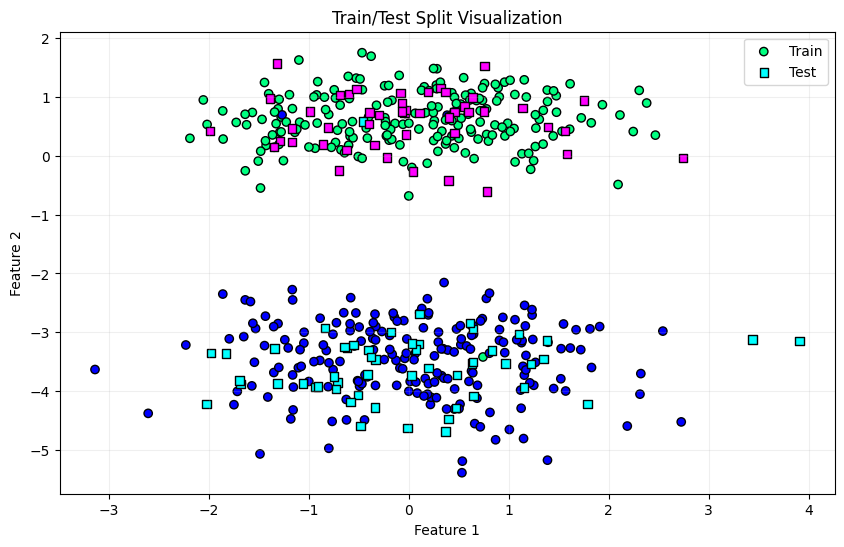

In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Generate dataset
X, y = make_classification(n_samples=500,
                           n_features=2,
                           n_informative=1,
                           n_redundant=0,
                           n_classes=2,
                           n_clusters_per_class=1,
                           random_state=41,
                           hypercube=False,
                           class_sep=20)

print(f"Shape of X, y: {X.shape}, {y.shape}\n")

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lor = LogisticRegression(penalty=None, solver='sag')
lor.fit(X_train, y_train)
print("Weights: ", lor.coef_)
print("Bias: ", lor.intercept_)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='winter', label='Train', edgecolor='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='cool', marker='s', label='Test', edgecolor='k')  
plt.title("Train/Test Split Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


Shape of X, y: (500, 2), (500,)

Weights:  [[0.39263978 2.69367168]]
Bias:  [3.40716388]
Accuracy: 0.99


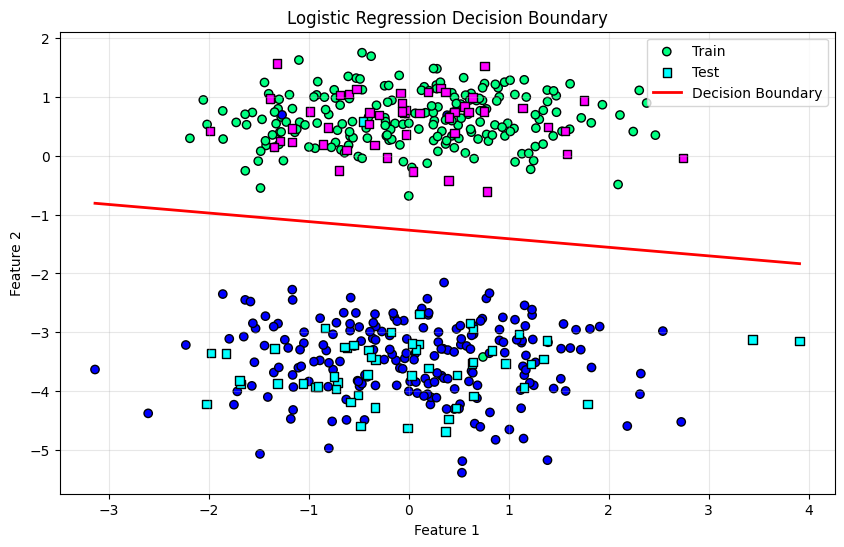

In [2]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate dataset
X, y = make_classification(n_samples=500,
                           n_features=2,
                           n_informative=1,
                           n_redundant=0,
                           n_classes=2,
                           n_clusters_per_class=1,
                           random_state=41,
                           hypercube=False,
                           class_sep=20)

print(f"Shape of X, y: {X.shape}, {y.shape}\n")

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train logistic regression model
lor = LogisticRegression(penalty=None, solver='sag', max_iter=1000)
lor.fit(X_train, y_train)
print("Weights: ", lor.coef_)
print("Bias: ", lor.intercept_)

# Predictions and accuracy
y_pred = lor.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Plot training and test points
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='winter', label='Train', edgecolor='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='cool', marker='s', label='Test', edgecolor='k')

# Plot the decision boundary
x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
# w0*x + w1*y + b = 0  -->  y = -(b + w0*x)/w1
w = lor.coef_[0]
b = lor.intercept_[0]
y_values = -(b + w[0] * x_values) / w[1]
plt.plot(x_values, y_values, color='red', linewidth=2, label='Decision Boundary')

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# **<font color="red">Custom Logistic Regression Class</font>**

Shape of X, y: (500, 2), (500,)

Epoch 1/2000 - log_loss: 0.213923
Epoch 201/2000 - log_loss: 0.052148
Epoch 401/2000 - log_loss: 0.050525
Epoch 601/2000 - log_loss: 0.050212
Epoch 801/2000 - log_loss: 0.050126
Epoch 1001/2000 - log_loss: 0.050100
Epoch 1201/2000 - log_loss: 0.050091
Epoch 1401/2000 - log_loss: 0.050088
Epoch 1601/2000 - log_loss: 0.050086
Epoch 1801/2000 - log_loss: 0.050086
Epoch 2000/2000 - log_loss: 0.050086
Custom model learned weights (coef): [0.39017058 2.691168  ]
Custom model learned bias (intercept): 3.401653082207699
Custom Model - Train accuracy: 0.9925, Test accuracy: 0.9900


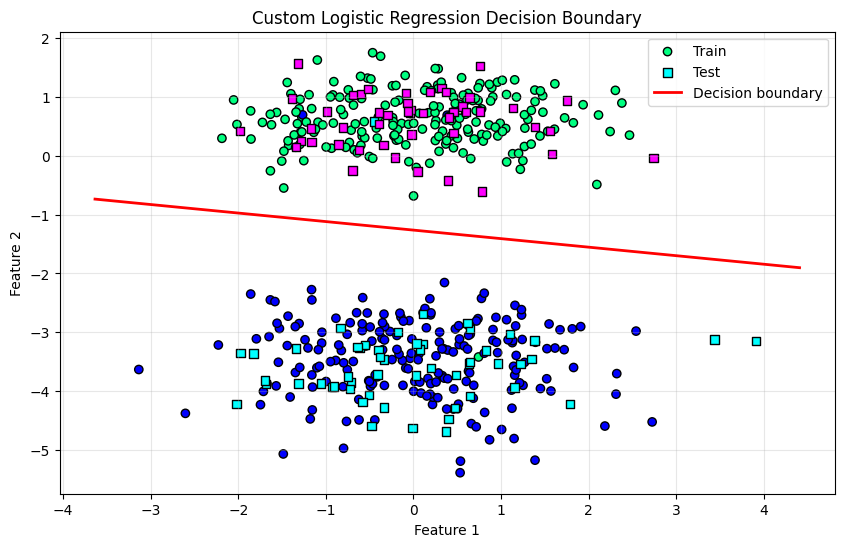

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

class LogisticRegression_GradientDescent:
    """
    Custom logistic regression using the gradient update:
        weights = weights + lr * (X.T @ (y - y_hat)) / N
    This follows the logic provided by the user.
    """

    def __init__(self, lr=0.5, epochs=1000, verbose=False):
        self.lr = lr
        self.epochs = int(epochs)
        self.verbose = verbose
        self.weights = None  # will hold bias as first element
    
    def _sigmoid(self, z):
        # numeric stability: clip input to avoid overflow of exp
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        """
        X: shape (N, d)
        y: shape (N,) with values 0 or 1
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        N, d = X.shape

        # insert bias column of 1s at index 0
        X_bias = np.insert(X, 0, 1.0, axis=1)  # shape (N, d+1)

        # initialize weights (including bias) to ones (per user's sketch)
        self.weights = np.ones(X_bias.shape[1], dtype=float)

        for epoch in range(self.epochs):
            # linear combination
            logits = X_bias.dot(self.weights)          # shape (N,)
            y_hat = self._sigmoid(logits)             # shape (N,)
            # update using the provided logic: weights + lr * (X.T @ (y - y_hat)) / N
            gradient_like = X_bias.T.dot(y - y_hat) / N
            self.weights = self.weights + self.lr * gradient_like

            if self.verbose and (epoch % max(1, self.epochs // 10) == 0 or epoch == self.epochs - 1):
                # compute a simple log-loss for feedback (optional)
                eps = 1e-15
                clipped = np.clip(y_hat, eps, 1 - eps)
                log_loss = -np.mean(y * np.log(clipped) + (1 - y) * np.log(1 - clipped))
                print(f"Epoch {epoch+1}/{self.epochs} - log_loss: {log_loss:.6f}")

        # separate weights and bias for convenience
        self.coef_ = self.weights[1:].copy()
        self.intercept_ = float(self.weights[0])
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        # insert bias column
        X_bias = np.insert(X, 0, 1.0, axis=1)
        logits = X_bias.dot(self.weights)
        return self._sigmoid(logits)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

    def accuracy(self, X, y, threshold=0.5):
        pred = self.predict(X, threshold=threshold)
        return np.mean(pred == np.asarray(y).reshape(-1))

# ---------------------------
# Example usage: end-to-end
# ---------------------------
def main():
    # Create dataset (same as you used)
    X, y = make_classification(n_samples=500,
                               n_features=2,
                               n_informative=1,
                               n_redundant=0,
                               n_classes=2,
                               n_clusters_per_class=1,
                               random_state=41,
                               hypercube=False,
                               class_sep=20)

    print(f"Shape of X, y: {X.shape}, {y.shape}\n")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train custom logistic regression
    custom_lr = LogisticRegression_GradientDescent(lr=0.5, epochs=2000, verbose=True)
    custom_lr.fit(X_train, y_train)

    print("Custom model learned weights (coef):", custom_lr.coef_)
    print("Custom model learned bias (intercept):", custom_lr.intercept_)

    # Accuracy
    train_acc = custom_lr.accuracy(X_train, y_train)
    test_acc = custom_lr.accuracy(X_test, y_test)
    print(f"Custom Model - Train accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}")

    # Plotting the data and decision boundary (for the custom model)
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='winter', label='Train', edgecolor='k')
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='cool', marker='s', label='Test', edgecolor='k')

    # Decision boundary line: w0 * 1 + w1*x + w2*y = 0  -> y = -(b + w1*x)/w2
    w = custom_lr.weights.copy()
    b = w[0]
    w1 = w[1]
    w2 = w[2]

    x_vals = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    if abs(w2) < 1e-8:
        # Nearly vertical boundary: x = -b / w1
        x_boundary = -b / w1 if abs(w1) > 1e-8 else None
        if x_boundary is not None:
            plt.axvline(x_boundary, color='red', linewidth=2, label='Decision boundary')
    else:
        y_vals = -(b + w1 * x_vals) / w2
        plt.plot(x_vals, y_vals, color='red', linewidth=2, label='Decision boundary')

    plt.title("Custom Logistic Regression Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


if __name__ == "__main__":
    main()


# *<font color="green">Comparison of Both Logistic Regressions</font>*

Shape of X, y: (500, 2), (500,)

Sklearn model weights (coef): [[0.39075693 2.69166767]]
Sklearn model bias (intercept): [3.40279371]
Sklearn Accuracy: 0.9900

Epoch 1/2000 - log_loss: 0.213923
Epoch 201/2000 - log_loss: 0.052148
Epoch 401/2000 - log_loss: 0.050525
Epoch 601/2000 - log_loss: 0.050212
Epoch 801/2000 - log_loss: 0.050126
Epoch 1001/2000 - log_loss: 0.050100
Epoch 1201/2000 - log_loss: 0.050091
Epoch 1401/2000 - log_loss: 0.050088
Epoch 1601/2000 - log_loss: 0.050086
Epoch 1801/2000 - log_loss: 0.050086
Epoch 2000/2000 - log_loss: 0.050086
Custom model learned weights (coef): [0.39017058 2.691168  ]
Custom model learned bias (intercept): 3.401653082207699
Custom Model - Train accuracy: 0.9925, Test accuracy: 0.9900


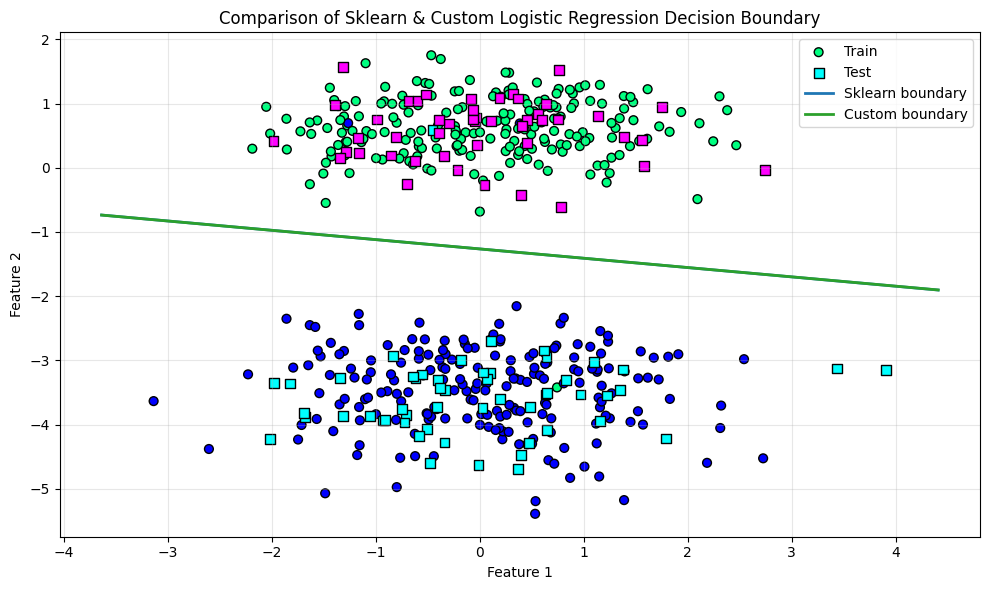

In [5]:
# compare_logistic_models.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -------------------------
# Your custom classifier
# -------------------------
class LogisticRegression_GradientDescent:
    """
    Custom logistic regression using the gradient update:
        weights = weights + lr * (X.T @ (y - y_hat)) / N
    """

    def __init__(self, lr=0.5, epochs=1000, verbose=False):
        self.lr = lr
        self.epochs = int(epochs)
        self.verbose = verbose
        self.weights = None  # will hold bias as first element

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        N, d = X.shape

        # insert bias column of 1s at index 0
        X_bias = np.insert(X, 0, 1.0, axis=1)  # shape (N, d+1)

        # initialize weights (including bias) to ones (per your sketch)
        self.weights = np.ones(X_bias.shape[1], dtype=float)

        for epoch in range(self.epochs):
            logits = X_bias.dot(self.weights)    # shape (N,)
            y_hat = self._sigmoid(logits)       # shape (N,)
            gradient_like = X_bias.T.dot(y - y_hat) / N
            self.weights = self.weights + self.lr * gradient_like

            if self.verbose and (epoch % max(1, self.epochs // 10) == 0 or epoch == self.epochs - 1):
                eps = 1e-15
                clipped = np.clip(y_hat, eps, 1 - eps)
                log_loss = -np.mean(y * np.log(clipped) + (1 - y) * np.log(1 - clipped))
                print(f"Epoch {epoch+1}/{self.epochs} - log_loss: {log_loss:.6f}")

        self.coef_ = self.weights[1:].copy()
        self.intercept_ = float(self.weights[0])
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        X_bias = np.insert(X, 0, 1.0, axis=1)
        logits = X_bias.dot(self.weights)
        return self._sigmoid(logits)

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

    def accuracy(self, X, y, threshold=0.5):
        pred = self.predict(X, threshold=threshold)
        return np.mean(pred == np.asarray(y).reshape(-1))


# -------------------------
# Main demonstration
# -------------------------
def main():
    # Create dataset (same as you used)
    X, y = make_classification(n_samples=500,
                               n_features=2,
                               n_informative=1,
                               n_redundant=0,
                               n_classes=2,
                               n_clusters_per_class=1,
                               random_state=41,
                               hypercube=False,
                               class_sep=20)

    print(f"Shape of X, y: {X.shape}, {y.shape}\n")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ----------------- sklearn Logistic Regression ---------------------
    # Use penalty='none' if supported; otherwise fall back safely.
    try:
        lor = LogisticRegression(penalty=None, solver='saga', max_iter=2000, random_state=0)
    except TypeError:
        # older sklearn versions may not accept penalty='none'
        lor = LogisticRegression(max_iter=2000, random_state=0)

    lor.fit(X_train, y_train)
    print("Sklearn model weights (coef):", lor.coef_)
    print("Sklearn model bias (intercept):", lor.intercept_)

    # Predictions and accuracy (sklearn)
    y_pred = lor.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Sklearn Accuracy: {accuracy:.4f}\n")

    # ------------------ custom Logistic Regression ---------------------
    custom_lr = LogisticRegression_GradientDescent(lr=0.5, epochs=2000, verbose=True)
    custom_lr.fit(X_train, y_train)

    print("Custom model learned weights (coef):", custom_lr.coef_)
    print("Custom model learned bias (intercept):", custom_lr.intercept_)

    # Accuracy (custom)
    train_acc = custom_lr.accuracy(X_train, y_train)
    test_acc = custom_lr.accuracy(X_test, y_test)
    print(f"Custom Model - Train accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}")

    # ----------------------- Plotting -------------------------------
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='winter', label='Train', edgecolor='k', s=40)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='cool', marker='s', label='Test', edgecolor='k', s=50)

    # Plot sklearn decision boundary (blue)
    x_values = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    w_skl = lor.coef_[0]         # shape (n_features,)
    b_skl = lor.intercept_[0]
    # check nonzero for second coefficient
    if abs(w_skl[1]) < 1e-12:
        # nearly vertical
        if abs(w_skl[0]) > 1e-12:
            x_boundary = -b_skl / w_skl[0]
            plt.axvline(x_boundary, color='tab:blue', linewidth=2, label='Sklearn boundary')
    else:
        y_values_skl = -(b_skl + w_skl[0] * x_values) / w_skl[1]
        plt.plot(x_values, y_values_skl, color='tab:blue', linewidth=2, label='Sklearn boundary')

    # Plot custom decision boundary (green)
    w = custom_lr.weights.copy()
    b = w[0]
    w1 = w[1]
    w2 = w[2]

    if abs(w2) < 1e-12:
        if abs(w1) > 1e-12:
            x_boundary = -b / w1
            plt.axvline(x_boundary, color='tab:green', linewidth=2, label='Custom boundary')
    else:
        y_vals = -(b + w1 * x_values) / w2
        plt.plot(x_values, y_vals, color='tab:green', linewidth=2, label='Custom boundary')

    plt.title("Comparison of Sklearn & Custom Logistic Regression Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
